#1. Introduction

Sentiment Analysis is a task in Natural Language Processing that focuses on identifying the emotional tone of text data. It is widely used to classify opinions as positive, negative, or neutral.

In [38]:
!pip -q install scikit-learn pandas opendatasets

#2. Data Collection

The first step is to gather textual data for analysis. Common sources include:

Movie reviews (e.g., IMDb dataset)

Social media (Twitter, Facebook comments)

Product reviews (Amazon, Flipkart)

Custom datasets (CSV files)

In [39]:
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis'
od.download(dataset_url)

Skipping, found downloaded files in "./twitter-entity-sentiment-analysis" (use force=True to force download)


In [40]:
import pandas as pd

df = pd.read_csv("/content/twitter-entity-sentiment-analysis/twitter_training.csv")
df.columns = ["id", "entity", "sentiment", "comment"]

df = df.dropna(subset=['comment'])
df = df.drop_duplicates(subset=['comment'])
df = df[df['sentiment'] != 'Irrelevant']

df = df.groupby('sentiment', group_keys=False)\
       .apply(lambda x: x.sample(n=10000, random_state=42))\
       .reset_index(drop=True)

print(df['sentiment'].value_counts())
df.head()

sentiment
Negative    10000
Neutral     10000
Positive    10000
Name: count, dtype: int64


/tmp/ipykernel_10060/2530877445.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=10000, random_state=42))\


,id,entity,sentiment,comment
0,9170,Nvidia,Negative,It's like @ nvidia wants us to buy @ AMDGaming...
1,11602,Verizon,Negative,Don't make making it no the better for Verizon...
2,12843,Xbox(Xseries),Negative,""" next whole gen possible performance "". "" mos..."
3,2227,CallOfDuty,Negative,That's why I love call of duty mobile game.
4,5979,HomeDepot,Negative,I was asked during my conversation yesterday t...


#3. Data Preprocessing

Raw text cannot be directly used by machine learning models. It must be cleaned and transformed.
###Steps involved:
###3.1 Lowercasing

Convert all text to lowercase to maintain consistency.

"Good Product" → "good product"
###3.2 Removing Noise

Punctuation

Numbers

Special characters

###3.3 Tokenization

Split text into individual words (tokens).

"this is good" → ["this", "is", "good"]
###3.4 Stopword Removal

Remove common words that do not add meaning:

“is”, “the”, “and”, etc.

###3.5 Stemming / Lemmatization

Reduce words to their base form:

"running" → "run"

"better" → "good" (lemmatization)

In [41]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply preprocessing to dataset column
df['comment'] = df['comment'].apply(preprocess)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,id,entity,sentiment,comment
0,9170,Nvidia,Negative,like nvidia want u buy amdgaming wanted buy gx...
1,11602,Verizon,Negative,make making better verizon shit closed unk
2,12843,Xbox(Xseries),Negative,next whole gen possible performance small xbox...
3,2227,CallOfDuty,Negative,love call duty mobile game
4,5979,HomeDepot,Negative,asked conversation yesterday name something fa...


In [42]:
# Sentiment Encoding
df['sentiment'] = df['sentiment'].map({'Positive':1, 'Negative':0, 'Neutral':2})
df.head()

,id,entity,sentiment,comment
0,9170,Nvidia,0,like nvidia want u buy amdgaming wanted buy gx...
1,11602,Verizon,0,make making better verizon shit closed unk
2,12843,Xbox(Xseries),0,next whole gen possible performance small xbox...
3,2227,CallOfDuty,0,love call duty mobile game
4,5979,HomeDepot,0,asked conversation yesterday name something fa...


#4. Feature Extraction

Machine learning models cannot understand text directly, so we convert text into numerical form.
We will use:
###TF-IDF (Term Frequency - Inverse Document Frequency)

This is a more advanced method that assigns importance to words.

TF (Term Frequency): Frequency of word in document

IDF (Inverse Document Frequency): Reduces importance of common words

Formula (conceptual):

TF-IDF = TF × IDF

It helps highlight important words like:

"excellent", "bad", "worst"

In [43]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['comment'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#5. Model Training using SVM
###What is SVM?

Support Vector Machine is a supervised machine learning algorithm used for classification tasks.

###Key Idea:

SVM finds the best boundary (hyperplane) that separates different classes.

###Steps in Training:

####5.1 Training the Model

Input: Feature vectors (TF-IDF or BoW)

Output: Sentiment labels

SVM learns to classify text by maximizing the margin between classes.

####5.2 Prediction

The trained model predicts sentiment for unseen data.

####5.3 Evaluation Metrics

Common metrics:

Accuracy → Overall correctness

Precision → Correct positive predictions

Recall → Coverage of actual positives

F1-score → Balance of precision & recall

In [45]:
from sklearn.svm import SVC

model = SVC(kernel='linear', probability=True)
model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', probability=True)

In [46]:
y_pred = model.predict(X_test_tfidf)

Accuracy: 0.8108333333333333
              precision    recall  f1-score   support

    negative       0.81      0.84      0.83      2000
    positive       0.79      0.81      0.80      2000
     neutral       0.83      0.78      0.80      2000

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



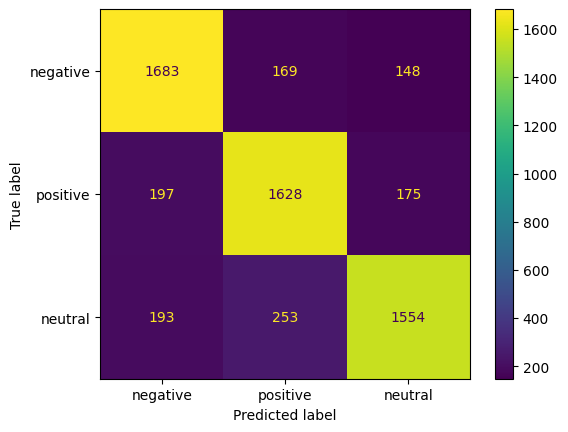

In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

sentiments = ['negative', 'positive', 'neutral']

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=sentiments))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=sentiments)
disp.plot()

plt.show()

#6. Test with Custom Input

In [48]:
def predict_sentiment(text):

    # Convert text to TF-IDF features
    cleaned = preprocess(text)
    text_tfidf = vectorizer.transform([cleaned]).toarray()

    # Predict sentiment
    prediction = model.predict(text_tfidf)[0]

    # Get probabilities
    probs = model.predict_proba(text_tfidf)[0]

    positive_prob = probs[1]
    negative_prob = probs[0]
    neutral_prob = probs[2]

    return prediction, positive_prob, negative_prob, neutral_prob

In [51]:
prediction, pos_prob, neg_prob, neutral_prob = predict_sentiment("today is wednesday")

if prediction == 1:
    sentiment = "Positive"
    prob = pos_prob
elif prediction == 0:
    sentiment = "Negative"
    prob = neg_prob
else:
    sentiment = "Neutral"
    prob = neutral_prob

print("Sentiment:", sentiment)
print("Confidence level:", round(prob, 2))

Sentiment: Neutral
Confidence level: 0.94


#7. Save Model

In [50]:
import pickle

# Save SVM model
with open("svm_sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

#8. Advantages of SVM in Sentiment Analysis

Works well with high-dimensional data (text features)

Effective for small and medium datasets

Handles sparse data efficiently

Good generalization performance

#9. Limitations

Computationally expensive for large datasets

Not ideal for very large-scale deep learning tasks

#10. Conclusion

Sentiment analysis involves multiple steps starting from raw text data to final prediction. By combining:

Proper preprocessing

Effective feature extraction (TF-IDF)

Robust models like SVM

we can build an accurate sentiment classification system.